In this notebook, we compare the morphological parameters from SExtractor in the R21 catalogues with actual galaxy images made with MUSE cubes. The goal is to figure out whether these parameters are useful for estimating galax sizes, which in turn can be used to estimate the degree to which cluster members contaminate targets

In [1]:
# Load megatable
from astropy.io import fits
from astropy.table import Table

megatab = Table(fits.open(f"./megatables/lae_megatab_1fwhm_opt.fits")[1].data)

In [2]:
# Generate a muse white light image centered on sources of interest 
megatab.sort("SNRR", reverse=True) # sort by SNRR to get the brightest sources first
# Restrict to a single cluster to speed up processing time
cluster_of_interest = "MACS0416NE"
megatab_interest = megatab[megatab["CLUSTER"] == cluster_of_interest]

N_sources = 3

sources_of_interest = megatab_interest[:N_sources]

sources_of_interest # display the sources of interest

iden,CLUSTER,idfrom,zconf,z,A_WORLD,B_WORLD,THETA_J2000,ISOAREAF_IMAGE,KRON_RADIUS,FLAGS,THRESHOLD,MU_MAX,CLASS_STAR,FWHM_IMAGE,FLUX_RADIUS,MAG_ISO_HST_F606W,MAGERR_ISO_HST_F606W,MAG_AUTO_HST_F606W,MAGERR_AUTO_HST_F606W,MAG_ISO_HST_F814W,MAGERR_ISO_HST_F814W,MAG_AUTO_HST_F814W,MAGERR_AUTO_HST_F814W,MAG_ISO_HST_F110W,MAGERR_ISO_HST_F110W,MAG_AUTO_HST_F110W,MAGERR_AUTO_HST_F110W,MAG_ISO_HST_F160W,MAGERR_ISO_HST_F160W,MAG_AUTO_HST_F160W,MAGERR_AUTO_HST_F160W,MU,MU_ERR,MUL,zforbid,zforbid_err,zlya,zlya_err,zabs,zabs_err,RA,DEC,FLUXB,FLUXB_ERR,FLUXR,FLUXR_ERR,AMPR,AMPR_ERR,AMPB,AMPB_ERR,LPEAKR,LPEAKR_ERR,LPEAKB,LPEAKB_ERR,FWHMR,FWHMR_ERR,FWHMB,FWHMB_ERR,DISPR,DISPR_ERR,DISPB,DISPB_ERR,SNRR,SNRB,ASYMR,ASYMR_ERR,ASYMB,ASYMB_ERR,CONT,CONT_ERR,SLOPE,SLOPE_ERR,TAU,TAU_ERR,FWHM_ABS,FWHM_ABS_ERR,LPEAK_ABS,LPEAK_ABS_ERR,Z_LYA,Z_LYA_ERR,FLUXB_UB,RCHSQ,FLAG,FLUX_AlII1671,FLUX_ERR_AlII1671,LPEAK_AlII1671,LPEAK_ERR_AlII1671,FWHM_AlII1671,FWHM_ERR_AlII1671,SNR_AlII1671,CONT_AlII1671,CONT_ERR_AlII1671,SLOPE_AlII1671,SLOPE_ERR_AlII1671,RCHSQ_AlII1671,FLAG_AlII1671,FLUX_AlIII1854,FLUX_ERR_AlIII1854,LPEAK_AlIII1854,LPEAK_ERR_AlIII1854,FWHM_AlIII1854,FWHM_ERR_AlIII1854,SNR_AlIII1854,CONT_AlIII1854,CONT_ERR_AlIII1854,SLOPE_AlIII1854,SLOPE_ERR_AlIII1854,RCHSQ_AlIII1854,FLAG_AlIII1854,FLUX_AlIII1862,FLUX_ERR_AlIII1862,LPEAK_AlIII1862,LPEAK_ERR_AlIII1862,FWHM_AlIII1862,FWHM_ERR_AlIII1862,SNR_AlIII1862,CONT_AlIII1862,CONT_ERR_AlIII1862,SLOPE_AlIII1862,SLOPE_ERR_AlIII1862,RCHSQ_AlIII1862,FLAG_AlIII1862,FLUX_CII1334,FLUX_ERR_CII1334,LPEAK_CII1334,LPEAK_ERR_CII1334,FWHM_CII1334,FWHM_ERR_CII1334,SNR_CII1334,CONT_CII1334,CONT_ERR_CII1334,SLOPE_CII1334,SLOPE_ERR_CII1334,RCHSQ_CII1334,FLAG_CII1334,FLUX_CII2329,FLUX_ERR_CII2329,LPEAK_CII2329,LPEAK_ERR_CII2329,FWHM_CII2329,FWHM_ERR_CII2329,SNR_CII2329,CONT_CII2329,CONT_ERR_CII2329,SLOPE_CII2329,SLOPE_ERR_CII2329,RCHSQ_CII2329,FLAG_CII2329,FLUX_CIII1907,FLUX_ERR_CIII1907,LPEAK_CIII1907,LPEAK_ERR_CIII1907,FWHM_CIII1907,FWHM_ERR_CIII1907,SNR_CIII1907,CONT_CIII1907,CONT_ERR_CIII1907,SLOPE_CIII1907,SLOPE_ERR_CIII1907,RCHSQ_CIII1907,FLAG_CIII1907,FLUX_CIII1909,FLUX_ERR_CIII1909,LPEAK_CIII1909,LPEAK_ERR_CIII1909,FWHM_CIII1909,FWHM_ERR_CIII1909,SNR_CIII1909,CONT_CIII1909,CONT_ERR_CIII1909,SLOPE_CIII1909,SLOPE_ERR_CIII1909,RCHSQ_CIII1909,FLAG_CIII1909,FLUX_CIV1548,FLUX_ERR_CIV1548,LPEAK_CIV1548,LPEAK_ERR_CIV1548,FWHM_CIV1548,FWHM_ERR_CIV1548,SNR_CIV1548,CONT_CIV1548,CONT_ERR_CIV1548,SLOPE_CIV1548,SLOPE_ERR_CIV1548,RCHSQ_CIV1548,FLAG_CIV1548,FLUX_CIV1551,FLUX_ERR_CIV1551,LPEAK_CIV1551,LPEAK_ERR_CIV1551,FWHM_CIV1551,FWHM_ERR_CIV1551,SNR_CIV1551,CONT_CIV1551,CONT_ERR_CIV1551,SLOPE_CIV1551,SLOPE_ERR_CIV1551,RCHSQ_CIV1551,FLAG_CIV1551,FLUX_FeII1608,FLUX_ERR_FeII1608,LPEAK_FeII1608,LPEAK_ERR_FeII1608,FWHM_FeII1608,FWHM_ERR_FeII1608,SNR_FeII1608,CONT_FeII1608,CONT_ERR_FeII1608,SLOPE_FeII1608,SLOPE_ERR_FeII1608,RCHSQ_FeII1608,FLAG_FeII1608,FLUX_FeII1611,FLUX_ERR_FeII1611,LPEAK_FeII1611,LPEAK_ERR_FeII1611,FWHM_FeII1611,FWHM_ERR_FeII1611,SNR_FeII1611,CONT_FeII1611,CONT_ERR_FeII1611,SLOPE_FeII1611,SLOPE_ERR_FeII1611,RCHSQ_FeII1611,FLAG_FeII1611,FLUX_HeII1640,FLUX_ERR_HeII1640,LPEAK_HeII1640,LPEAK_ERR_HeII1640,FWHM_HeII1640,FWHM_ERR_HeII1640,SNR_HeII1640,CONT_HeII1640,CONT_ERR_HeII1640,SLOPE_HeII1640,SLOPE_ERR_HeII1640,RCHSQ_HeII1640,FLAG_HeII1640,FLUX_NIII1750,FLUX_ERR_NIII1750,LPEAK_NIII1750,LPEAK_ERR_NIII1750,FWHM_NIII1750,FWHM_ERR_NIII1750,SNR_NIII1750,CONT_NIII1750,CONT_ERR_NIII1750,SLOPE_NIII1750,SLOPE_ERR_NIII1750,RCHSQ_NIII1750,FLAG_NIII1750,FLUX_NIV1483,FLUX_ERR_NIV1483,LPEAK_NIV1483,LPEAK_ERR_NIV1483,FWHM_NIV1483,FWHM_ERR_NIV1483,SNR_NIV1483,CONT_NIV1483,CONT_ERR_NIV1483,SLOPE_NIV1483,SLOPE_ERR_NIV1483,RCHSQ_NIV1483,FLAG_NIV1483,FLUX_NIV1487,FLUX_ERR_NIV1487,LPEAK_NIV1487,LPEAK_ERR_NIV1487,FWHM_NIV1487,FWHM_ERR_NIV1487,SNR_NIV1487,CONT_NIV1487,CONT_ERR_NIV1487,SLOPE_NIV1487,SLOPE_ERR_NIV1487,RCHSQ_NIV1487,FLAG_NIV1487,FLUX_NV1238,FLUX_ERR_NV1238,LPEAK_NV1238,LPEAK_ERR_NV1238,FWHM_NV1238,FWHM_ERR_NV1238,SNR_NV1238,CONT_NV123

Loading MACS0416NE cube...
Done.
Generating image...


/home/james/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Found 15 nearby sources for source ID P1172


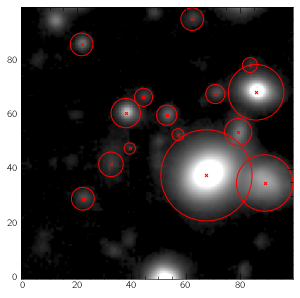

Loading MACS0416NE cube...
Done.
Generating image...


/home/james/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Found 10 nearby sources for source ID P617


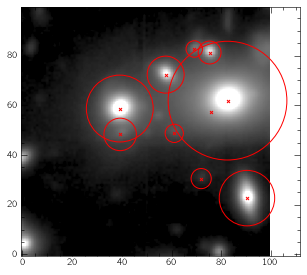

Loading MACS0416NE cube...
Done.
Generating image...


/home/james/.local/lib/python3.9/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Found 6 nearby sources for source ID P1569


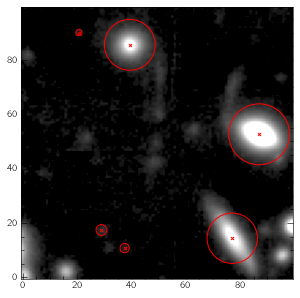

In [23]:
# For each source, make a muse whte light image cutout centered on it, and plot an ellipse showing the SExtractor morphological
# parameters (A_WORLD, B_WORLD, THETA_J2000) from the R21 tables for nearby sources
from tangelo.quality_control import find_nearby_sources
from tangelo.image_processing import make_muse_img

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.colors import PowerNorm

from astropy.coordinates import SkyCoord
from astropy import units as u
import numpy as np

cutout_size = 10 # arcseconds

for source in sources_of_interest:
    source_id = source["iden"]
    source_ra = source["RA"]
    source_dec = source["DEC"]

    # Make a muse white light image cutout centered on the source
    muse_img = make_muse_img(source, cutout_size * 2, 6000, 1000)

    fig, ax = plt.subplots(figsize=(5, 5))
    # Set reasonable stretch limits for the white light image
    vmin = 0
    vmax = np.percentile(muse_img.data, 99) # Use the 99th percentile to avoid outliers dominating the stretch
    ax.imshow(muse_img.data, origin="lower", cmap="gray", norm=PowerNorm(0.5, vmin=vmin, vmax=vmax))

    # Find nearby sources in the R21 tables
    nearby_sources = find_nearby_sources(source, maxdist=cutout_size)

    print(f"Found {len(nearby_sources)} nearby sources for source ID {source_id}")

    # Plot an ellipse for each nearby source using the SExtractor morphological parameters
    for nearby_source in nearby_sources:
        nearby_source_id = nearby_source["iden"]
        ra = nearby_source["RA"]
        dec = nearby_source["DEC"]
        a_world = nearby_source["A_WORLD"] * np.nan # In degrees
        b_world = nearby_source["B_WORLD"] * np.nan # in degrees
        theta_j2000 = nearby_source["THETA_J2000"]

        # define a scaling-up factor for the ellipse size
        scaling_factor = 5

        # Convert the SExtractor parameters to pixel units (assuming a pixel scale of 0.2 arcsec/pixel)
        a_pix = a_world / (0.2 / 3600) # Convert from degrees to arcseconds, then to pixels
        b_pix = b_world / (0.2 / 3600) # Convert from degrees to arcseconds, then to pixels

        # Raise a warning if any of the parameters are NaN
        if np.isnan(a_world) or np.isnan(b_world) or np.isnan(theta_j2000):
            print(f"Warning: NaN value found in SExtractor parameters for nearby source ID {nearby_source_id} "
                  f"at RA={ra}, DEC={dec}. Plotting circle using ISOAREAF_IMAGE instead")
            a_pix_hst = np.sqrt(nearby_source["ISOAREAF_IMAGE"] / np.pi) # Convert ISOAREAF_IMAGE to an equivalent radius
            b_pix_hst = a_pix_hst # Use the same value for b_pix to create a circle
            # Convert from HST to MUSE pixel scale
            a_pix = a_pix_hst * (0.03 / 0.2)
            b_pix = b_pix_hst * (0.03 / 0.2)
            theta_j2000 = 0 # Set the angle to 0 for a circle

        position = SkyCoord(ra=ra*u.degree, dec=dec*u.degree)
        position_pix = muse_img.wcs.wcs.world_to_pixel(position)

        ax.scatter(position_pix[0], position_pix[1], color="red", marker="x") # Mark the center of the nearby source with a red "x"

        # Create an ellipse patch and add it to the plot
        ellipse = Ellipse((position_pix[0], position_pix[1]), 
                          width=a_pix * scaling_factor, height=b_pix * scaling_factor, 
                          angle=theta_j2000, edgecolor="red", facecolor="none")
        ax.add_patch(ellipse)

    plt.show()

In [6]:
muse_img.wcs?

Type:        WCS
String form:
WCS Keywords
           
           Number of WCS axes: 2
           CTYPE : 'RA---TAN'  'DEC--TAN'
           CRVAL : 64.0440345073  -24.0 <...>  -3.9283710065919e-05
           CD2_1 CD2_2  : -3.9283710065919e-05  3.9283710065919e-05
           NAXIS : 50  50
File:        ~/.local/lib/python3.9/site-packages/mpdaf/obj/coords.py
Docstring:  
The WCS class manages the world coordinates of the spatial axes of
MPDAF images, using the pywcs package.

Note that MPDAF images are stored in python arrays that are
indexed in [y,x] axis order. In general the axes of these arrays
are not along celestial axes such as right-ascension and
declination. They are cartesian axes of a flat map projection of
the sky around the observation center, and they may be rotated
away from the celestial axes. When their rotation angle is zero,
the Y axis is parallel to the declination axis. However the X axis
is only along the right ascension axis for observations at zero
declination.